# Student Performance — Complete Machine Learning Workflow

This notebook performs a complete machine-learning workflow on the **Student Habits & Performance** dataset:

**EDA → Data Preparation → Linear Regression → Classification → Evaluation → Train/Test Comparison → Findings → 5 Meaningful Insights**

The regression target is `exam_score`. For classification, `exam_score >= 50` is treated as **Pass** and values below 50 as **Fail**.

> **Important:** `exam_score` is never used as an input feature for either model. For classification, the Pass/Fail label is derived from `exam_score`, and the original score is excluded from the predictors to avoid target leakage.


In [1]:
# 1. Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## 2. Load the Dataset

In [2]:

import os

FILE_PATH = "Day18_19_student_habits_performance.csv"

if not os.path.exists(FILE_PATH):
    try:
        from google.colab import files
        uploaded = files.upload()
        FILE_PATH = next(iter(uploaded))
    except Exception:
        # Fallback for the supplied environment
        fallback = "/mnt/data/Day18_19_student_habits_performance.csv"
        if os.path.exists(fallback):
            FILE_PATH = fallback
        else:
            raise FileNotFoundError(
                "CSV not found. Place Day18_19_student_habits_performance.csv "
                "in the notebook folder or upload it in Colab."
            )

df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Saving Day18_19_student_habits_performance.csv to Day18_19_student_habits_performance.csv
Dataset shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 3. Initial Dataset Inspection

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
missing = df.isnull().sum().to_frame("missing_count")
missing["missing_percentage"] = 100 * missing["missing_count"] / len(df)
display(missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False))


Column names:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Data types:


,dtype
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality           

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Duplicate rows: 0

Missing values:


,missing_count,missing_percentage
parental_education_level,91,9.1


### Numerical and categorical variables

- **Numerical variables** are continuous or discrete measurements such as age, study hours, attendance, sleep, exercise frequency, mental-health rating, and exam score.
- **Categorical variables** describe groups such as gender, part-time job, diet quality, parental education, internet quality, and extracurricular participation.
- `student_id` is an identifier and is not useful as a predictive feature, so it will be excluded from the models.


In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)


Numerical variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


## 4. Data Cleaning Checks

In [5]:
# Check missing values and duplicate IDs/rows.
print("Total duplicate rows:", df.duplicated().sum())
print("Unique student IDs:", df["student_id"].nunique(), "out of", len(df))

# Missing values will be handled inside the ML preprocessing pipeline.
# Parental education level has missing values in this dataset.


Total duplicate rows: 0
Unique student IDs: 1000 out of 1000


## 5. EDA — Distributions of Numerical Variables

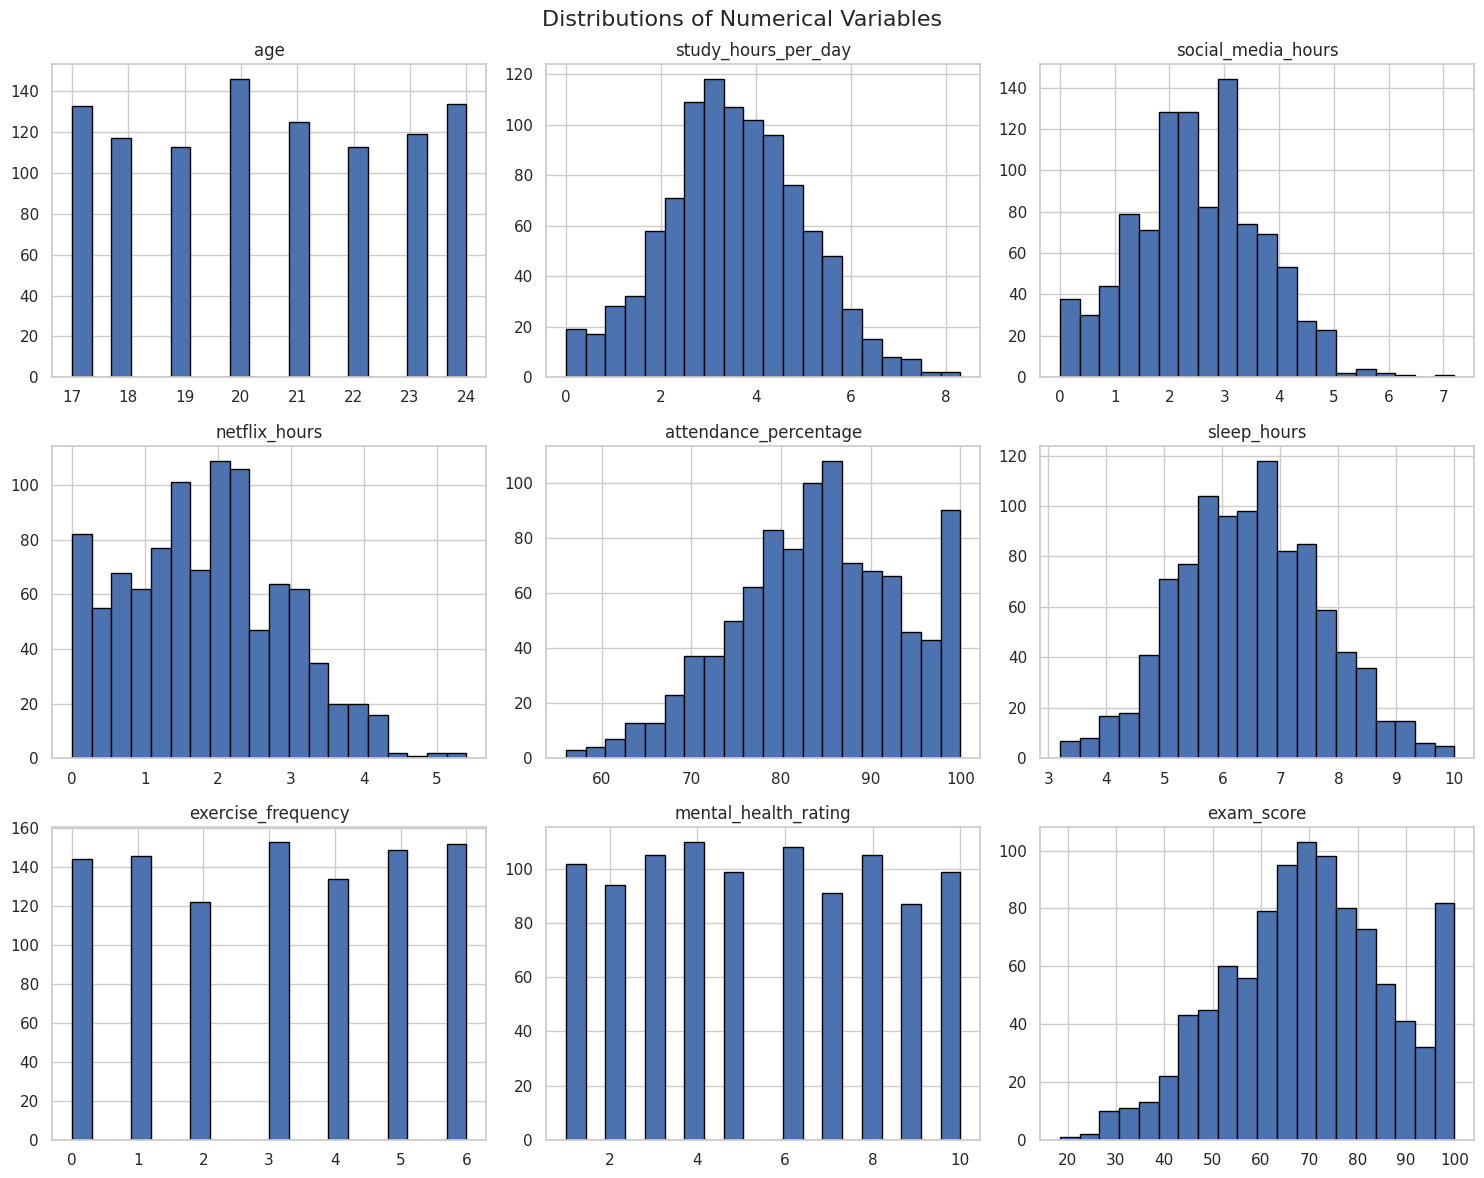

In [6]:
# Histograms for all numerical variables
df[numeric_cols].hist(figsize=(15, 12), bins=20, edgecolor="black")
plt.suptitle("Distributions of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()


## 6. EDA — Exam Score Distribution

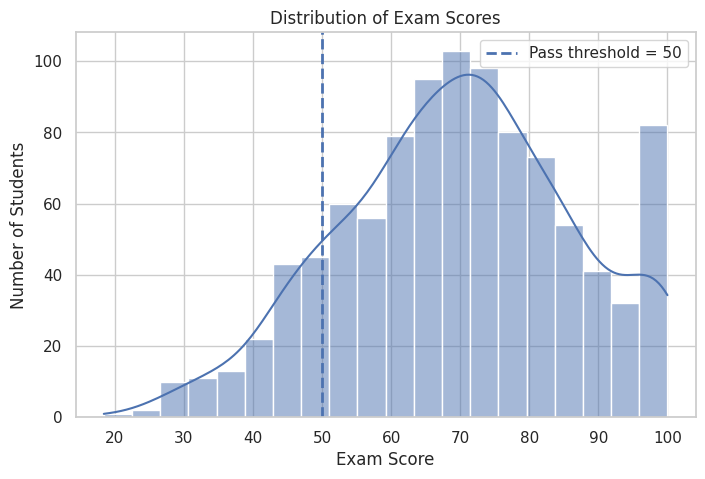

count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64


In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["exam_score"], bins=20, kde=True)
plt.axvline(50, linestyle="--", linewidth=2, label="Pass threshold = 50")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

print(df["exam_score"].describe())


## 7. EDA — Potential Outliers

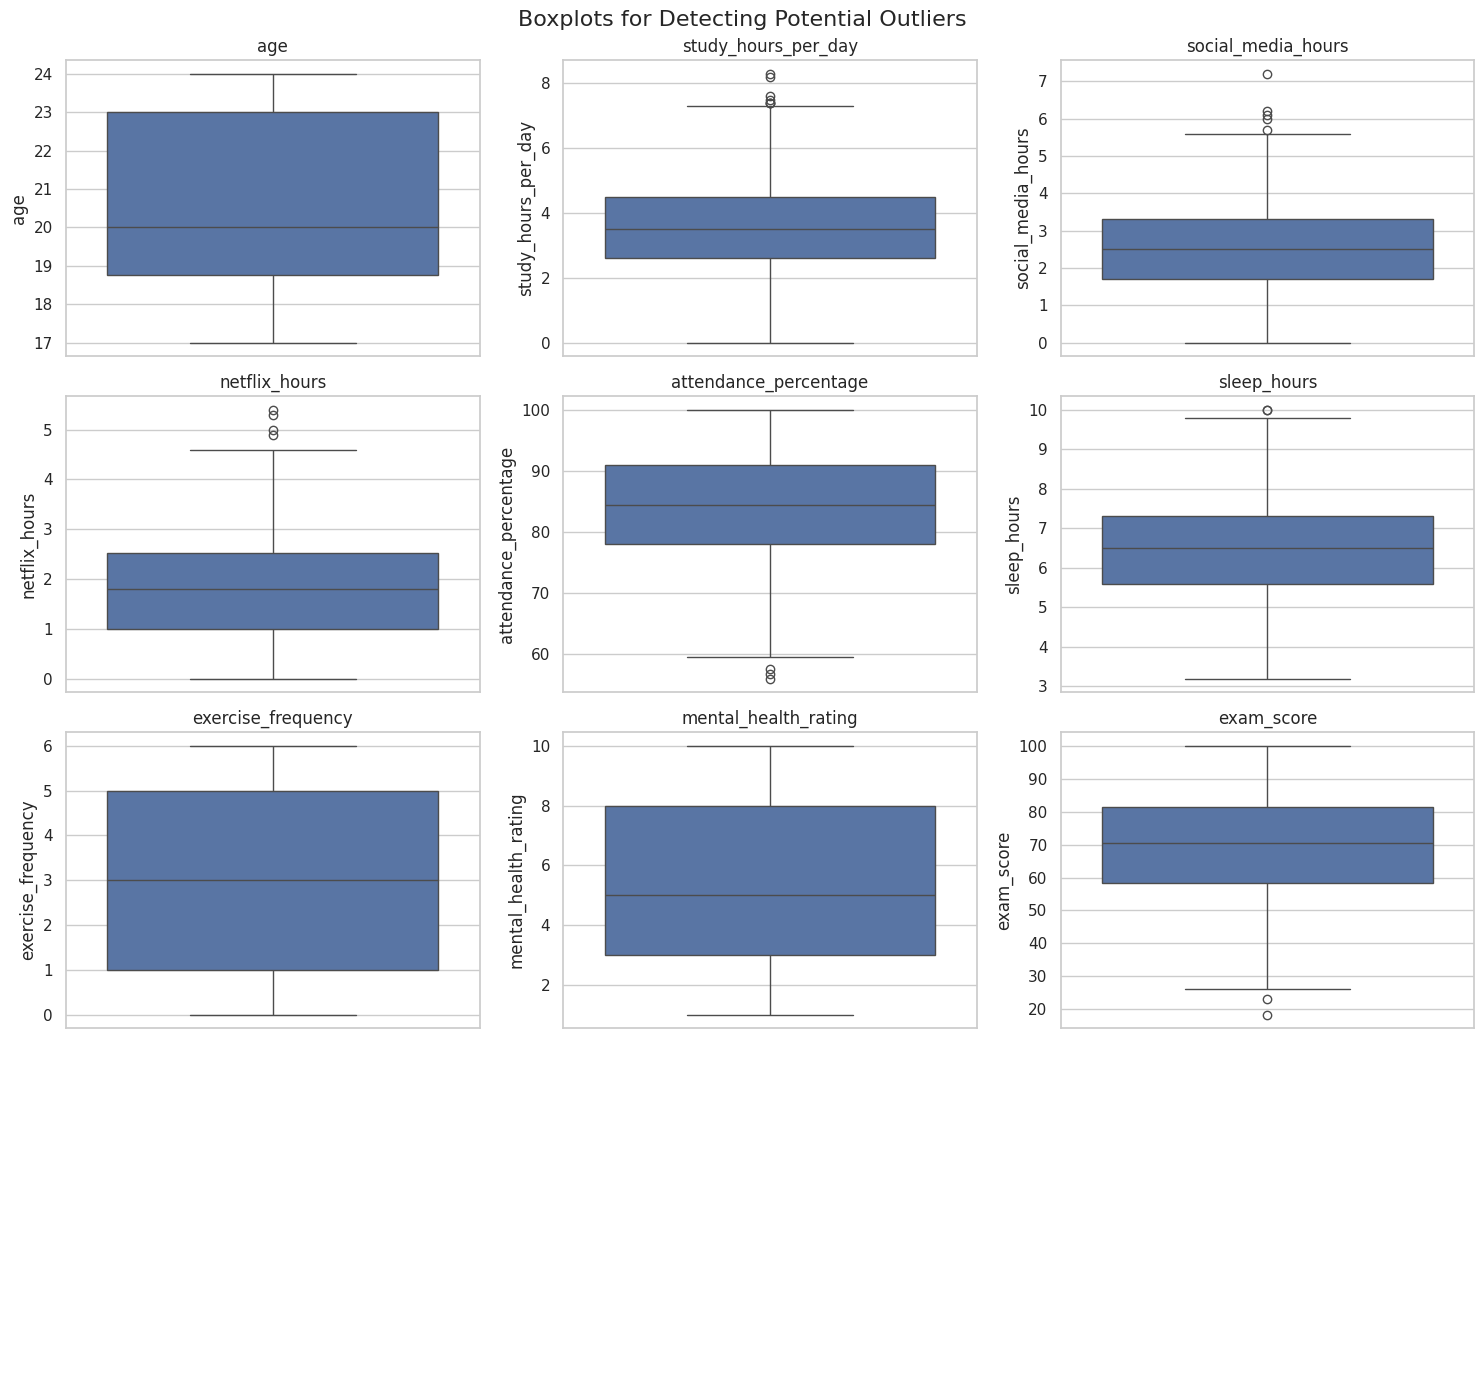

,variable,lower_bound,upper_bound,outlier_count,outlier_percentage
1,study_hours_per_day,-0.2500,7.3500,7,0.7
2,social_media_hours,-0.7000,5.7000,5,0.5
3,netflix_hours,-1.2875,4.8125,4,0.4
4,attendance_percentage,58.4625,110.5625,3,0.3
5,sleep_hours,3.0500,9.8500,2,0.2
8,exam_score,24.2000,115.6000,2,0.2
0,age,12.3750,29.3750,0,0.0
6,exercise_frequency,-5.0000,11.0000,0,0.0
7,mental_health_rating,-4.5000,15.5000,0,0.0


In [8]:
# Boxplots for numerical variables
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Boxplots for Detecting Potential Outliers", fontsize=16)
plt.tight_layout()
plt.show()

# IQR-based outlier counts
outlier_rows = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append([col, lower, upper, count, 100 * count / len(df)])

outlier_table = pd.DataFrame(
    outlier_rows,
    columns=["variable", "lower_bound", "upper_bound", "outlier_count", "outlier_percentage"]
).sort_values("outlier_count", ascending=False)

display(outlier_table)


## 8. EDA — Categorical Variables


--- student_id ---


,count
student_id,
S1999,1
S1000,1
S1001,1
S1002,1
S1003,1
...,...
S1012,1
S1011,1
S1010,1



--- gender ---


,count
gender,
Female,481
Male,477
Other,42



--- part_time_job ---


...

,count
parental_education_level,
High School,392
Bachelor,350
Master,167
NaN,91



--- internet_quality ---


,count
internet_quality,
Good,447
Average,391
Poor,162



--- extracurricular_participation ---


,count
extracurricular_participation,
No,682
Yes,318


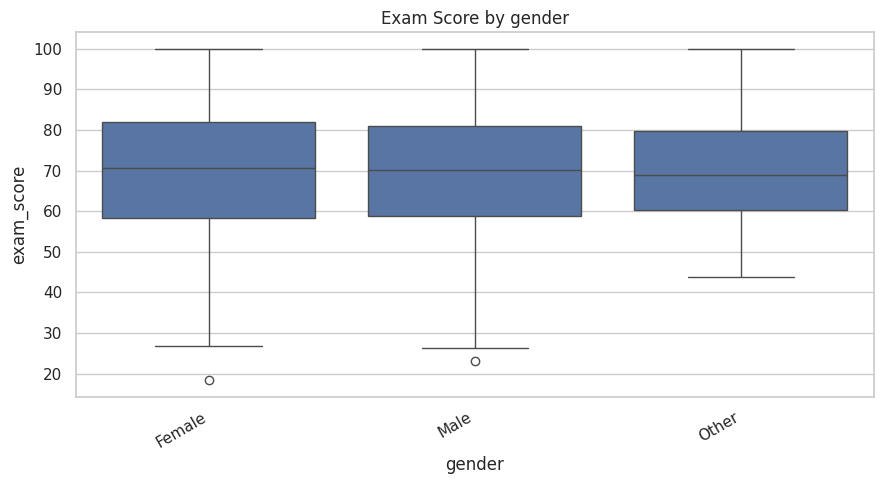

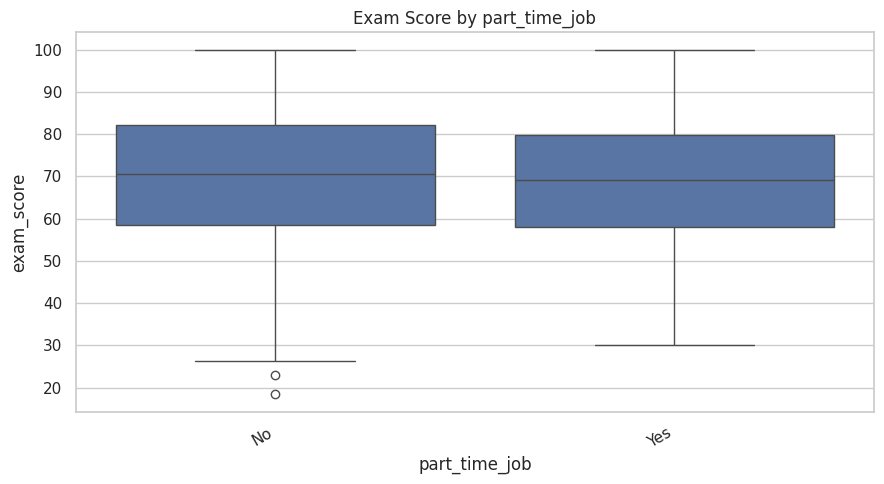

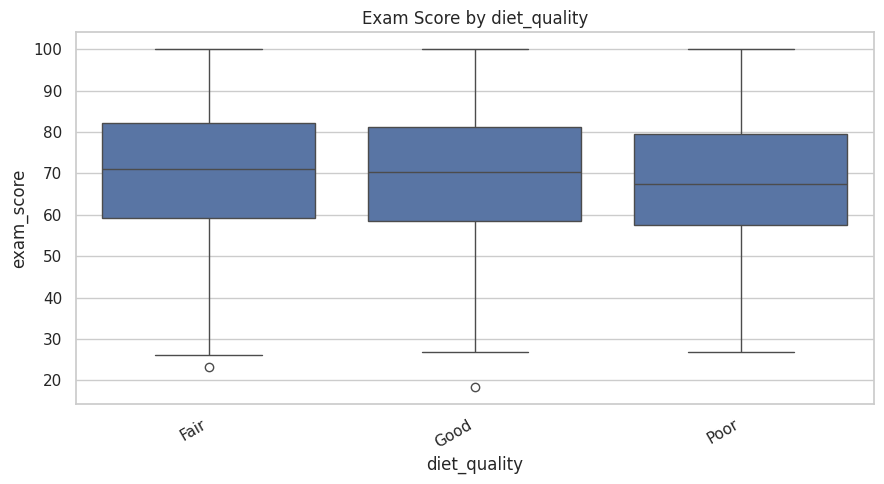

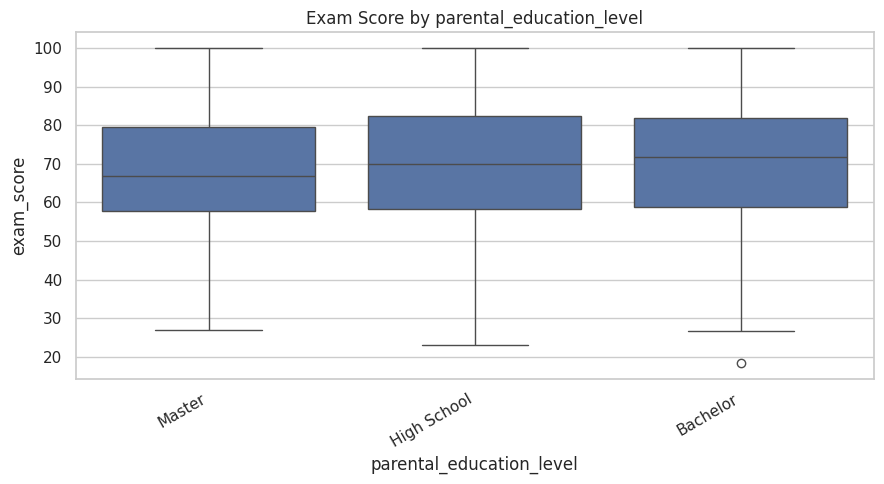

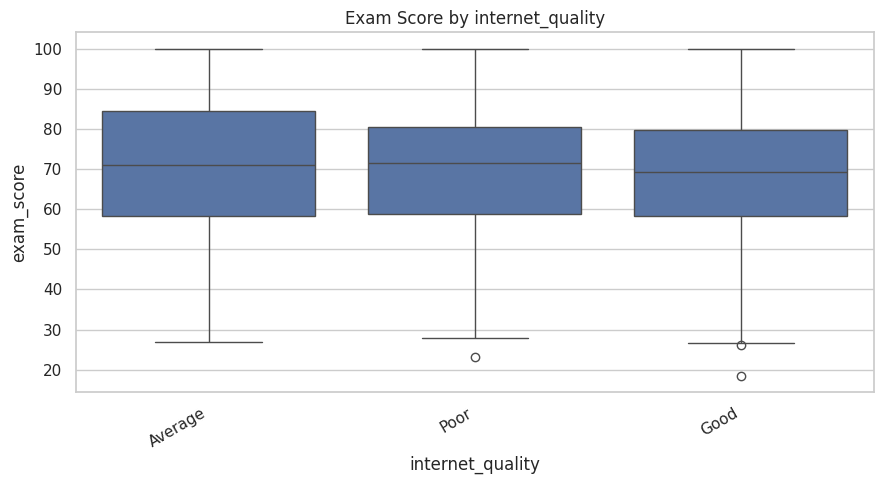

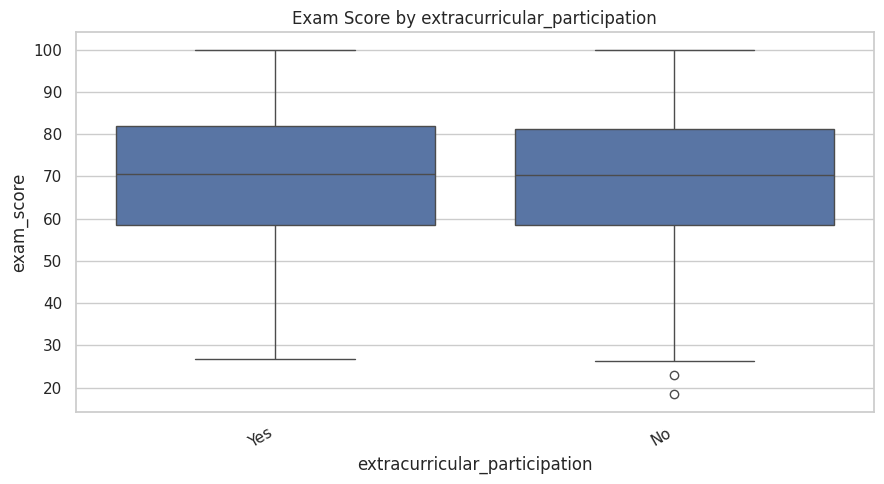

In [9]:
# Display value counts for each categorical variable
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).to_frame("count"))

# Relationship of categorical variables with exam_score
cat_for_plot = [c for c in categorical_cols if c != "student_id"]

for col in cat_for_plot:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x=col, y="exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 9. EDA — Numerical Relationships with Exam Score

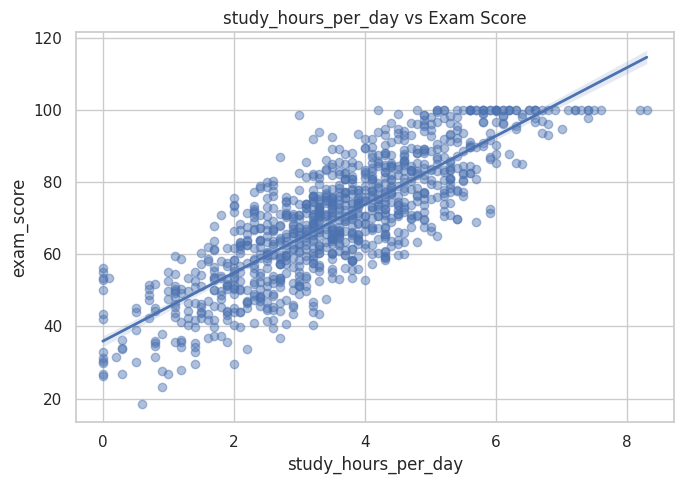

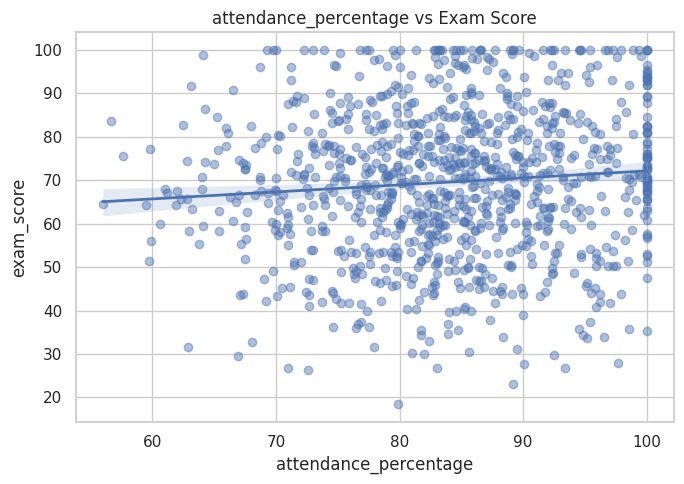

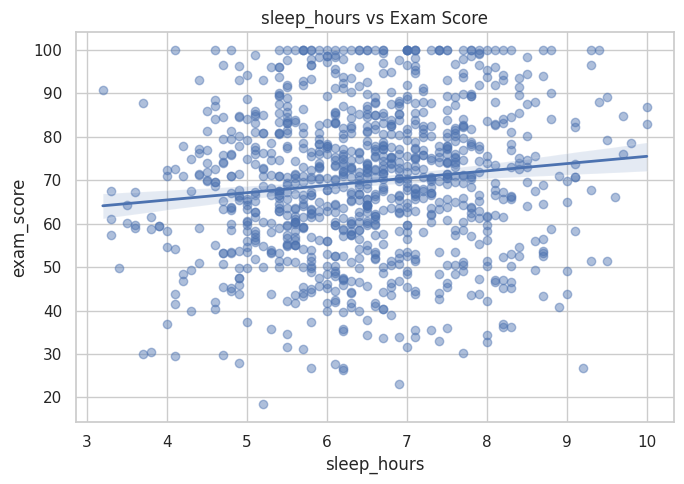

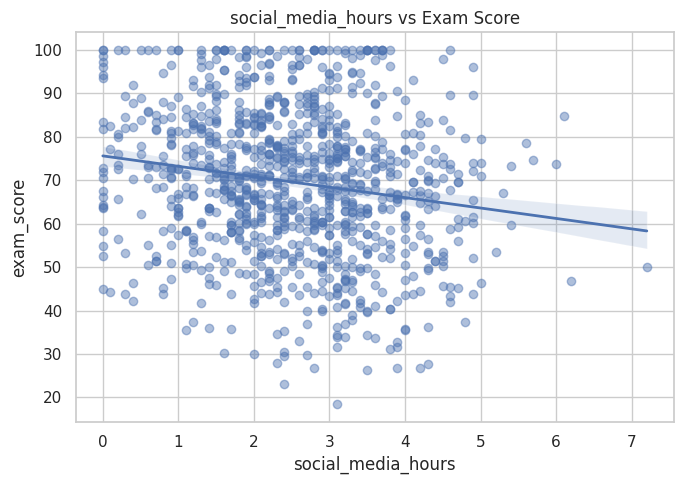

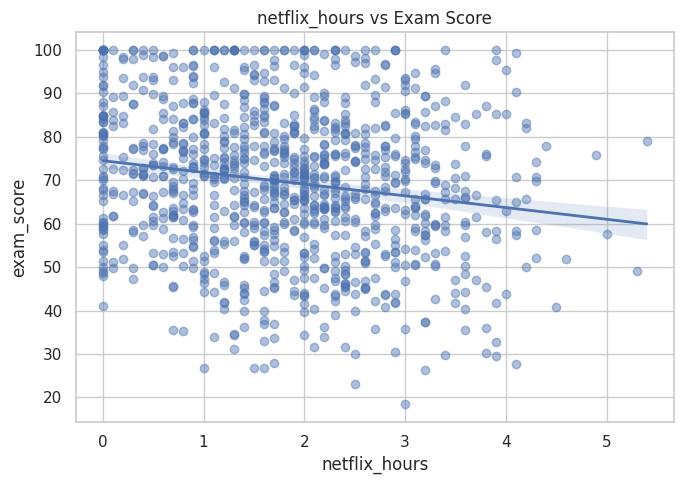

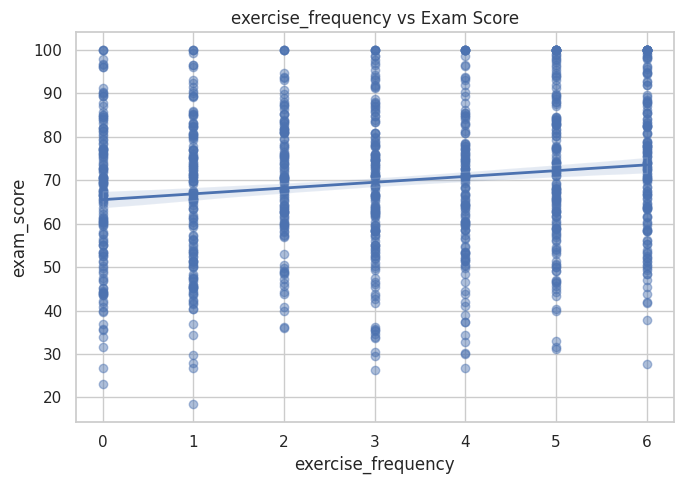

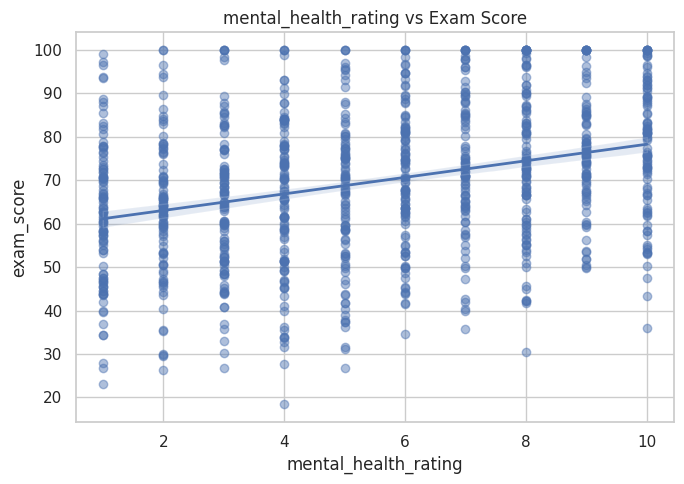

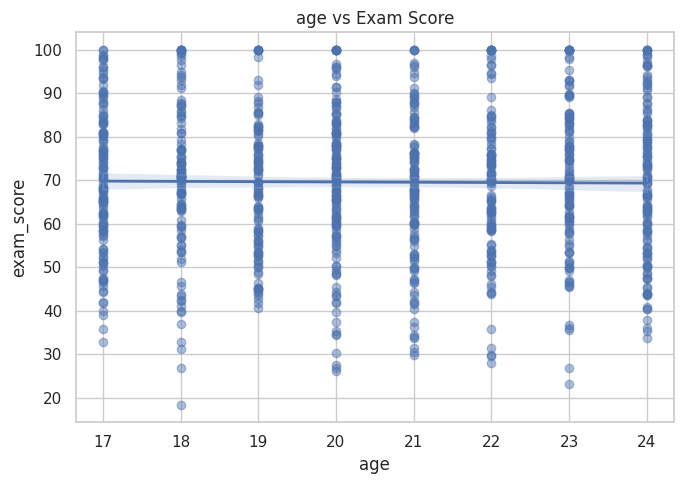

In [10]:
# Scatter/regression plots for the main numerical predictors
candidate_numeric = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "exercise_frequency",
    "mental_health_rating",
    "age"
]

for col in [c for c in candidate_numeric if c in df.columns]:
    plt.figure(figsize=(7, 5))
    sns.regplot(data=df, x=col, y="exam_score",
                scatter_kws={"alpha": 0.45}, line_kws={"linewidth": 2})
    plt.title(f"{col} vs Exam Score")
    plt.tight_layout()
    plt.show()


## 10. EDA — Correlation Analysis

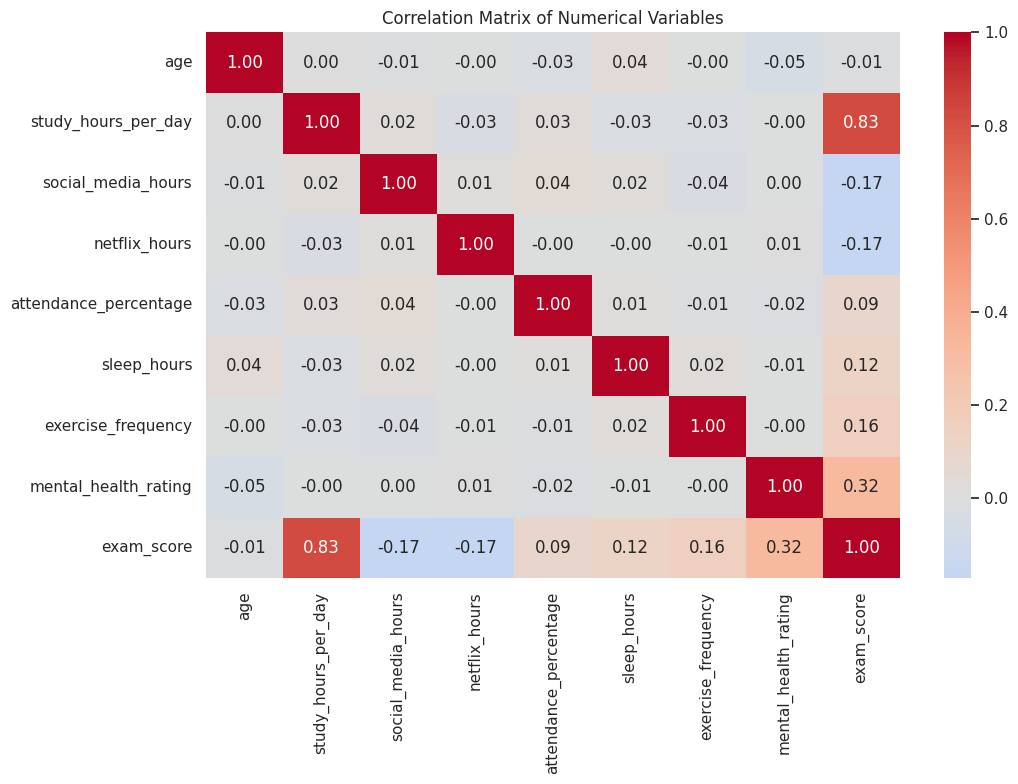

Numerical variables ranked by absolute correlation with exam_score:


,correlation_with_exam_score
study_hours_per_day,0.825419
mental_health_rating,0.321523
netflix_hours,-0.171779
social_media_hours,-0.166733
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907


In [11]:
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

exam_corr = corr["exam_score"].drop("exam_score").sort_values(key=lambda s: s.abs(), ascending=False)
print("Numerical variables ranked by absolute correlation with exam_score:")
display(exam_corr.to_frame("correlation_with_exam_score"))


### Interpreting correlation

Correlation measures the **strength and direction of linear association**. A positive value means the variables tend to increase together, while a negative value means one tends to decrease as the other increases.

Correlation does **not** prove causation. The plots and group comparisons should therefore be considered together with the model results.


## 11. EDA — Grouped Exam-Score Summaries

In [12]:
# Mean exam score by each categorical variable
for col in cat_for_plot:
    summary = (
        df.groupby(col, dropna=False)["exam_score"]
          .agg(["count", "mean", "median", "std"])
          .sort_values("mean", ascending=False)
    )
    print(f"\nExam-score summary by {col}:")
    display(summary)

# Quick numerical summary: correlation and means
numeric_summary = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "std": df[numeric_cols].std(),
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max()
})
display(numeric_summary)



Exam-score summary by gender:


,count,mean,median,std
gender,,,,
Other,42,70.647619,69.0,13.755890
Female,481,69.741372,70.7,16.899351
Male,477,69.368344,70.2,17.150875



Exam-score summary by part_time_job:


,count,mean,median,std
part_time_job,,,,
No,785,69.836561,70.6,16.975240
Yes,215,68.743256,69.2,16.578917



Exam-score summary by diet_quality:


...


Exam-score summary by internet_quality:


,count,mean,median,std
internet_quality,,,,
Average,391,70.643990,71.0,18.013482
Poor,162,69.717284,71.4,15.888382
Good,447,68.647651,69.3,16.190587



Exam-score summary by extracurricular_participation:


,count,mean,median,std
extracurricular_participation,,,,
Yes,318,69.623270,70.65,17.312389
No,682,69.591349,70.35,16.700140


,mean,median,std,min,max
age,20.4980,20.0,2.308100,17.0,24.0
study_hours_per_day,3.5501,3.5,1.468890,0.0,8.3
social_media_hours,2.5055,2.5,1.172422,0.0,7.2
netflix_hours,1.8197,1.8,1.075118,0.0,5.4
attendance_percentage,84.1317,84.4,9.399246,56.0,100.0
sleep_hours,6.4701,6.5,1.226377,3.2,10.0
exercise_frequency,3.0420,3.0,2.025423,0.0,6.0
mental_health_rating,5.4380,5.0,2.847501,1.0,10.0
exam_score,69.6015,70.5,16.888564,18.4,100.0


## 12. Prepare Data for Machine Learning

### Feature selection

The model will use the available student-habit and demographic variables that can reasonably be used as predictors.

- `student_id` is excluded because it is an identifier.
- `exam_score` is the regression target and is excluded from the predictors.
- Categorical variables are one-hot encoded.
- Missing categorical values are imputed with the most frequent category.
- Numerical variables are imputed with the median and standardized.
- The preprocessing is placed inside a **Pipeline/ColumnTransformer**, preventing preprocessing leakage from the test set into training.


In [13]:
# Define predictors and regression target
target = "exam_score"

feature_cols = [c for c in df.columns if c not in ["student_id", target]]
X = df[feature_cols].copy()
y = df[target].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Features used:")
print(feature_cols)
print("\nNumerical features:", numeric_features)
print("Categorical features:", categorical_features)


Features used:
['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']

Numerical features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical features: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [14]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Same train/test split is reused for regression and classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 800
Testing samples: 200


## 13. Linear Regression

In [15]:
regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

regression_model.fit(X_train, y_train)

y_train_pred = regression_model.predict(X_train)
y_test_pred = regression_model.predict(X_test)

def regression_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(actual, predicted)
    }

reg_train_metrics = regression_metrics(y_train, y_train_pred)
reg_test_metrics = regression_metrics(y_test, y_test_pred)

regression_results = pd.DataFrame(
    [reg_train_metrics, reg_test_metrics],
    index=["Training", "Testing"]
)

display(regression_results.round(4))


,MAE,MSE,RMSE,R2
Training,4.2142,28.5661,5.3447,0.9021
Testing,4.1923,26.5325,5.1510,0.8965


### Regression evaluation

- **MAE**: average absolute prediction error in marks.
- **MSE**: average squared prediction error; larger errors receive more penalty.
- **RMSE**: square root of MSE, expressed in the same units as exam score.
- **R²**: proportion of variance in exam score explained by the model. Higher is generally better.


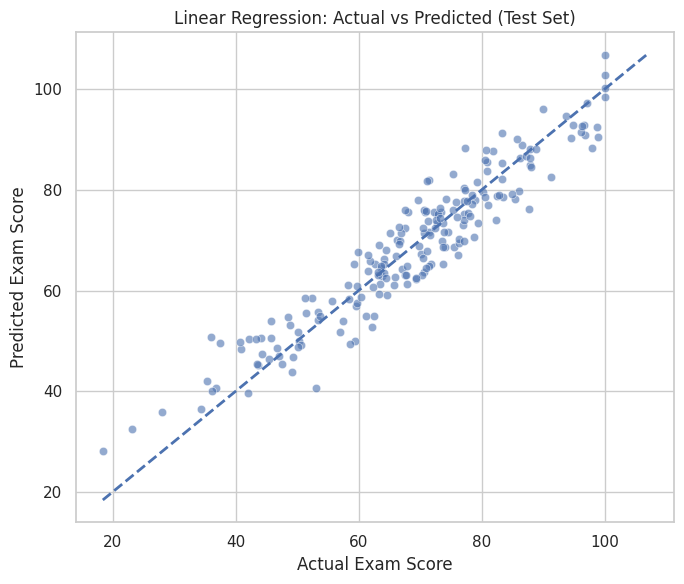

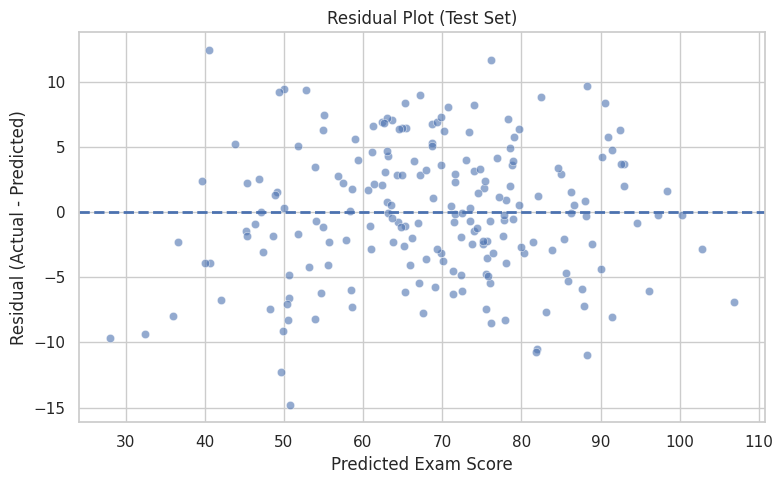

In [16]:
# Actual vs predicted exam scores
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
lims = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max())
]
plt.plot(lims, lims, linestyle="--", linewidth=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression: Actual vs Predicted (Test Set)")
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Test Set)")
plt.tight_layout()
plt.show()


## 14. Classification — Pass/Fail

In [17]:
# Create Pass/Fail target from exam_score.
# 50 or above = Pass; below 50 = Fail.
df["pass_fail"] = np.where(df["exam_score"] >= 50, "Pass", "Fail")

print("Class distribution:")
display(df["pass_fail"].value_counts().to_frame("count"))
display((df["pass_fail"].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))

# Classification uses exactly the same predictor set as regression.
X_cls = df[feature_cols].copy()
y_cls = df["pass_fail"].copy()

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)

classifier = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

classifier.fit(Xc_train, yc_train)

yc_train_pred = classifier.predict(Xc_train)
yc_test_pred = classifier.predict(Xc_test)


Class distribution:


,count
pass_fail,
Pass,869
Fail,131


,percentage
pass_fail,
Pass,86.9
Fail,13.1


## 15. Classification Evaluation

The classification model is evaluated using:

- **Confusion matrix**
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

Because the classes may not be perfectly balanced, precision, recall and F1-score are reported alongside accuracy.


In [18]:
# Classification metrics
def classification_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted, pos_label="Pass", zero_division=0),
        "Recall": recall_score(actual, predicted, pos_label="Pass", zero_division=0),
        "F1-score": f1_score(actual, predicted, pos_label="Pass", zero_division=0)
    }

cls_train_metrics = classification_metrics(yc_train, yc_train_pred)
cls_test_metrics = classification_metrics(yc_test, yc_test_pred)

classification_results = pd.DataFrame(
    [cls_train_metrics, cls_test_metrics],
    index=["Training", "Testing"]
)

display(classification_results.round(4))

print("\nTest-set classification report:")
print(classification_report(yc_test, yc_test_pred, zero_division=0))


,Accuracy,Precision,Recall,F1-score
Training,0.9575,0.9701,0.9813,0.9757
Testing,0.9550,0.9714,0.9770,0.9742



Test-set classification report:
              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



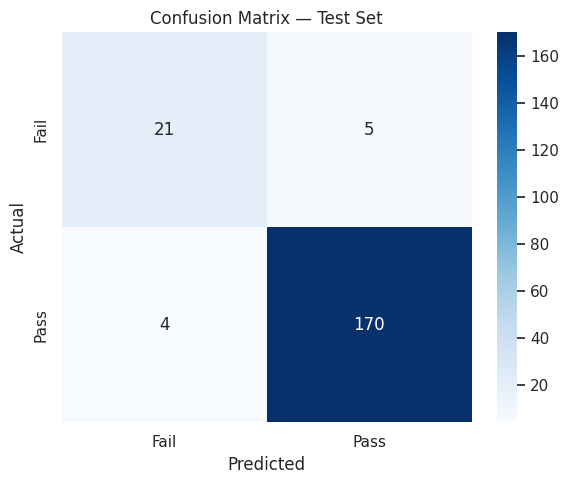

Confusion matrix layout:
Rows = Actual [Fail, Pass]
Columns = Predicted [Fail, Pass]


In [19]:
# Confusion matrix for the test set
labels = ["Fail", "Pass"]
cm = confusion_matrix(yc_test, yc_test_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

print("Confusion matrix layout:")
print("Rows = Actual [Fail, Pass]")
print("Columns = Predicted [Fail, Pass]")


## 16. Training vs Testing Performance — Overfitting/Underfitting

In [20]:
print("Regression:")
display(regression_results.round(4))

print("\nClassification:")
display(classification_results.round(4))

# Simple generalization-gap calculations
reg_r2_gap = reg_train_metrics["R2"] - reg_test_metrics["R2"]
reg_rmse_gap = reg_test_metrics["RMSE"] - reg_train_metrics["RMSE"]

cls_acc_gap = cls_train_metrics["Accuracy"] - cls_test_metrics["Accuracy"]
cls_f1_gap = cls_train_metrics["F1-score"] - cls_test_metrics["F1-score"]

print(f"\nRegression R² train-test gap: {reg_r2_gap:.4f}")
print(f"Regression RMSE test-train gap: {reg_rmse_gap:.4f}")
print(f"Classification accuracy train-test gap: {cls_acc_gap:.4f}")
print(f"Classification F1 train-test gap: {cls_f1_gap:.4f}")

# Practical interpretation rather than a hard statistical cutoff.
if reg_r2_gap > 0.10 or cls_acc_gap > 0.10:
    print("\nInterpretation: There is a noticeable train-test gap, suggesting possible overfitting.")
elif reg_test_metrics["R2"] < 0.30 and cls_test_metrics["Accuracy"] < 0.70:
    print("\nInterpretation: Both models have limited predictive performance, suggesting possible underfitting.")
else:
    print("\nInterpretation: Train and test performance are reasonably close, so there is no strong evidence of severe overfitting.")


Regression:


,MAE,MSE,RMSE,R2
Training,4.2142,28.5661,5.3447,0.9021
Testing,4.1923,26.5325,5.1510,0.8965



Classification:


,Accuracy,Precision,Recall,F1-score
Training,0.9575,0.9701,0.9813,0.9757
Testing,0.9550,0.9714,0.9770,0.9742



Regression R² train-test gap: 0.0056
Regression RMSE test-train gap: -0.1937
Classification accuracy train-test gap: 0.0025
Classification F1 train-test gap: 0.0015

Interpretation: Train and test performance are reasonably close, so there is no strong evidence of severe overfitting.


## 17. Most Important Regression Factors

In [21]:
# Extract linear-regression coefficients after preprocessing.
feature_names = regression_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = regression_model.named_steps["model"].coef_

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()

print("Largest positive coefficients:")
display(coef_table.sort_values("coefficient", ascending=False).head(10))

print("Largest negative coefficients:")
display(coef_table.sort_values("coefficient", ascending=True).head(10))


Largest positive coefficients:


,feature,coefficient,abs_coefficient
1,num__study_hours_per_day,14.144790,14.144790
7,num__mental_health_rating,5.565088,5.565088
6,num__exercise_frequency,2.656671,2.656671
5,num__sleep_hours,2.421865,2.421865
4,num__attendance_percentage,1.349632,1.349632
13,cat__diet_quality_Fair,0.502625,0.502625
10,cat__gender_Other,0.491633,0.491633
16,cat__parental_education_level_Bachelor,0.409879,0.409879
12,cat__part_time_job_Yes,0.187295,0.187295
0,num__age,0.113344,0.113344


Largest negative coefficients:


,feature,coefficient,abs_coefficient
2,num__social_media_hours,-3.129732,3.129732
3,num__netflix_hours,-2.531563,2.531563
14,cat__diet_quality_Good,-0.455348,0.455348
8,cat__gender_Female,-0.315648,0.315648
18,cat__parental_education_level_Master,-0.291919,0.291919
11,cat__part_time_job_No,-0.187295,0.187295
9,cat__gender_Male,-0.175985,0.175985
20,cat__internet_quality_Good,-0.136678,0.136678
17,cat__parental_education_level_High School,-0.117960,0.117960
23,cat__extracurricular_participation_Yes,-0.056861,0.056861


### Important caution about coefficients

For numerical variables, coefficients are based on standardized values because the preprocessing pipeline scales numeric features. For categorical variables, coefficients represent effects relative to the omitted/reference category created by one-hot encoding.

Coefficient magnitude is useful for interpretation within this linear model, but it should not automatically be interpreted as causal importance.


## 18. Key Findings and Final Five Insights

In [22]:
# Generate dataset-supported findings automatically from the actual data.
score_mean = df["exam_score"].mean()
score_median = df["exam_score"].median()
pass_rate = (df["exam_score"] >= 50).mean() * 100

corr_sorted = df[numeric_cols].corr()["exam_score"].drop("exam_score")
strongest_positive = corr_sorted.idxmax()
strongest_negative = corr_sorted.idxmin()

cat_means = {}
for col in cat_for_plot:
    grouped = df.groupby(col, dropna=False)["exam_score"].mean()
    if len(grouped) >= 2:
        best_group = grouped.idxmax()
        worst_group = grouped.idxmin()
        cat_means[col] = (best_group, grouped.max(), worst_group, grouped.min())

print(f"Average exam score: {score_mean:.2f}")
print(f"Median exam score: {score_median:.2f}")
print(f"Pass rate (>=50): {pass_rate:.2f}%")
print(f"Strongest positive numerical correlation: {strongest_positive} ({corr_sorted[strongest_positive]:.3f})")
print(f"Strongest negative numerical correlation: {strongest_negative} ({corr_sorted[strongest_negative]:.3f})")

print("\nFive meaningful insights supported by the analysis:")
print(f"1. The dataset contains {len(df):,} students, with an average exam score of {score_mean:.2f} and a median of {score_median:.2f}.")
print(f"2. {pass_rate:.2f}% of students meet the 50-mark passing threshold, showing the overall balance between Pass and Fail outcomes.")
print(f"3. {strongest_positive} has the strongest positive linear correlation with exam_score among the numerical variables ({corr_sorted[strongest_positive]:.3f}); this makes it an important factor to examine.")
print(f"4. {strongest_negative} has the strongest negative linear correlation with exam_score ({corr_sorted[strongest_negative]:.3f}); higher values of this variable are associated with lower scores in this dataset.")
print(f"5. The regression model's test R² is {reg_test_metrics['R2']:.3f} with RMSE {reg_test_metrics['RMSE']:.3f}, while the classification model's test accuracy is {cls_test_metrics['Accuracy']:.3f} and F1-score is {cls_test_metrics['F1-score']:.3f}. These results show how well the selected student-habit variables can predict performance and pass/fail status.")


Average exam score: 69.60
Median exam score: 70.50
Pass rate (>=50): 86.90%
Strongest positive numerical correlation: study_hours_per_day (0.825)
Strongest negative numerical correlation: netflix_hours (-0.172)

Five meaningful insights supported by the analysis:
1. The dataset contains 1,000 students, with an average exam score of 69.60 and a median of 70.50.
2. 86.90% of students meet the 50-mark passing threshold, showing the overall balance between Pass and Fail outcomes.
3. study_hours_per_day has the strongest positive linear correlation with exam_score among the numerical variables (0.825); this makes it an important factor to examine.
4. netflix_hours has the strongest negative linear correlation with exam_score (-0.172); higher values of this variable are associated with lower scores in this dataset.
5. The regression model's test R² is 0.897 with RMSE 5.151, while the classification model's test accuracy is 0.955 and F1-score is 0.974. These results show how well the selected

## 19. Conclusion

The analysis follows a complete machine-learning workflow from exploratory analysis to predictive modeling.

The EDA identifies distributions, missing values, potential outliers, relationships, correlations, and group-level differences in exam performance. The machine-learning stage then uses appropriate preprocessing and a fixed train/test split to build a **Linear Regression** model for exam scores and a **Logistic Regression** classifier for Pass/Fail.

The final train/test comparison should be used to judge generalization. A small difference between training and testing performance suggests better generalization, while a large training advantage may indicate overfitting. If both training and testing performance are weak, the model may be underfitting or the available features may not contain enough information to explain exam performance.

### Overall takeaway

Student performance is related to a combination of academic habits, attendance, lifestyle variables, well-being, and demographic/contextual factors. However, these relationships are associations in this dataset and should not be interpreted as proof that one factor directly causes a change in exam performance.


---
### Submission note

This notebook is designed to run in **Google Colab or Jupyter Notebook**. The numerical results, plots, confusion matrix, coefficients, and final insights are generated from the uploaded dataset when the notebook is executed.
